Загружаем данные из файла
Исходный размер данных: (396749, 20)
Дубликатов по order_rk: 0
После удаления дубликатов: (396749, 20)
После фильтрации: 396,228 поездок


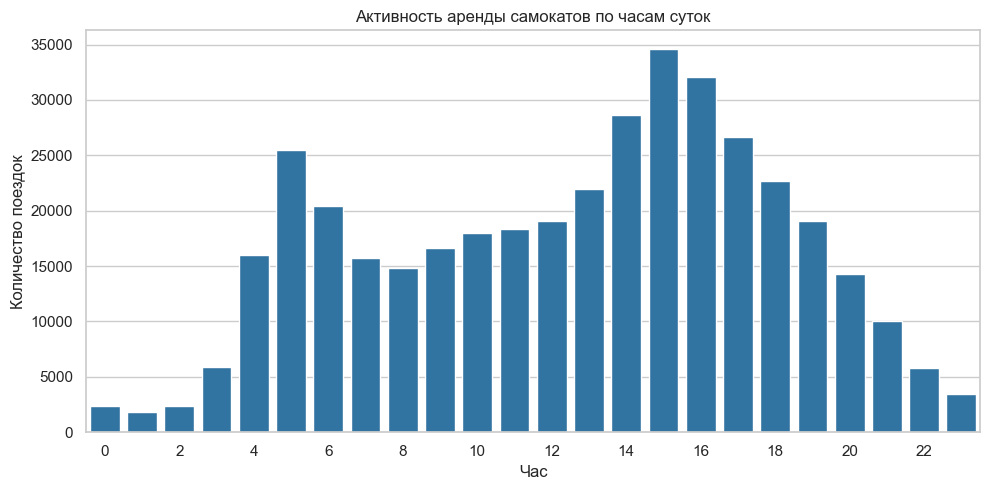

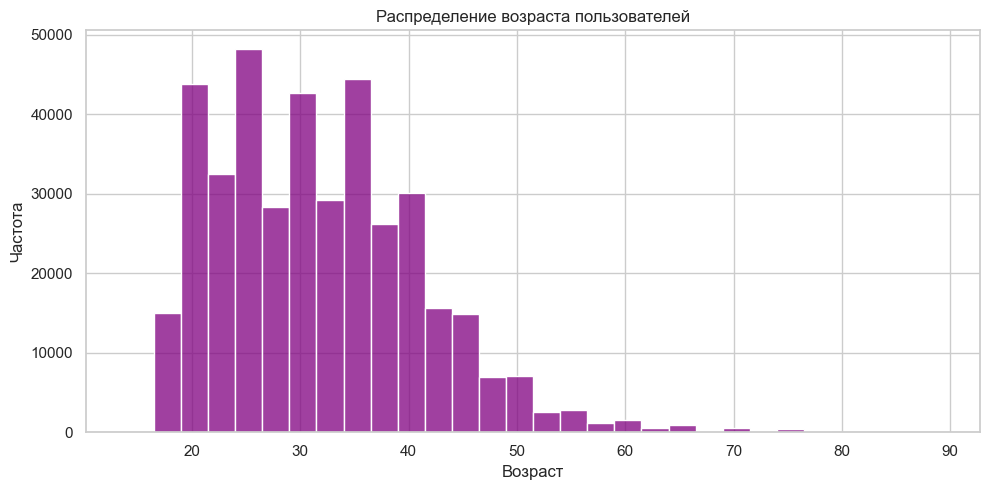

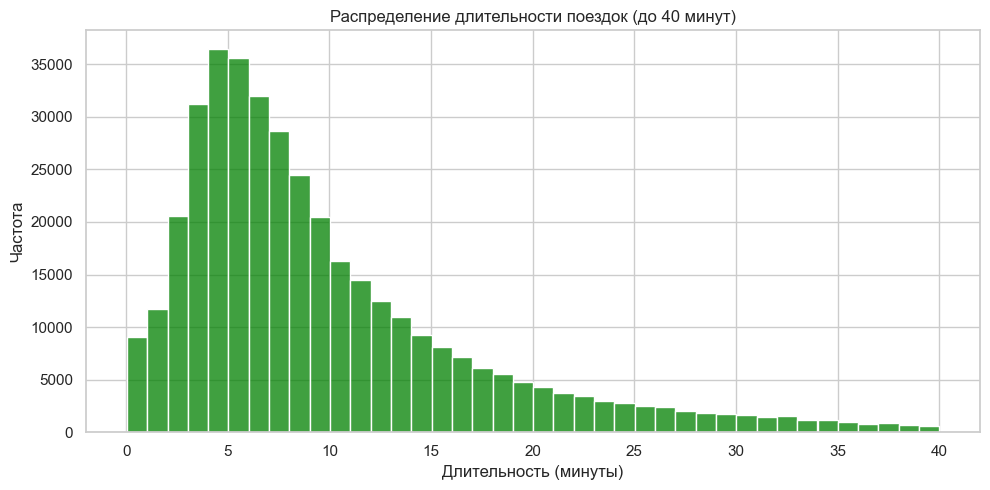

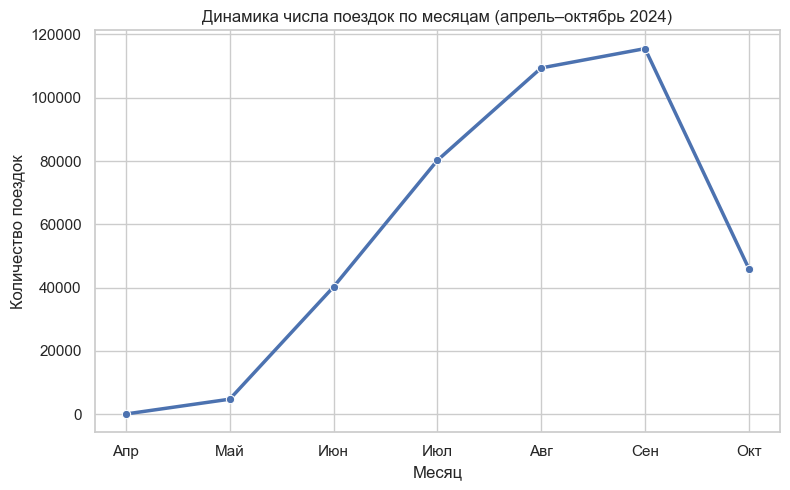


ОСНОВНЫЕ МЕТРИКИ
Всего поездок: 396,228
Уникальных пользователей: 63,970
Средняя длительность поездки: 11.4 мин
Медианная дистанция: 1.73 км
Средняя стоимость поездки: 127.4 у.е.
Доля поездок с кэшбэком в рублях: 92.5%
Доля поездок с кэшбэком в бонусах: 5.5%
Пик активности по часам: [14, 15, 16, 17]


In [ ]:
# -*- coding: utf-8 -*-
"""
EDA: Аренда самокатов через Т-Банк (апрель–октябрь 2024)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Настройки отображения
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

# --- ЗАГРУЗКА ДАННЫХ ---
print("Загружаем данные из файла")
df = pd.read_excel('1.xlsx', engine='openpyxl')

print(f"Исходный размер данных: {df.shape}")
print(f"Дубликатов по order_rk: {df.duplicated('order_rk').sum()}")
df = df.drop_duplicates(subset='order_rk', keep='first').copy()
print(f"После удаления дубликатов: {df.shape}")

# --- ПРЕОБРАЗОВАНИЕ ВРЕМЕННЫХ СТОЛБЦОВ ---
time_cols = ['created_dttm', 'book_start_dttm', 'book_end_dttm', 'local_book_start_dttm']
for col in time_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Расчёт длительности поездки в минутах
df['ride_duration_min'] = (df['book_end_dttm'] - df['book_start_dttm']).dt.total_seconds() / 60

# --- ОЧИСТКА ДАННЫХ ---
df = df[
    (df['ride_duration_min'] > 0) &
    (df['ride_duration_min'] <= 1440) &      # ≤ 24 часа
    (df['distance_km'] >= 0) &
    (df['distance_km'] <= 50) &              # адекватная дистанция
    (df['age'] >= 14) &
    (df['age'] <= 90) &
    (df['nominal_price_rub_amt'] >= 0)
].copy()

print(f"После фильтрации: {df.shape[0]:,} поездок")

# --- СОЗДАНИЕ ВРЕМЕННЫХ ФИЧ ---
df['hour'] = df['local_book_start_dttm'].dt.hour
df['dow'] = df['local_book_start_dttm'].dt.dayofweek  # Пн=0, Вс=6
df['month'] = df['local_book_start_dttm'].dt.month

# --- ВИЗУАЛИЗАЦИИ ---

# 1. Активность по часам суток
plt.figure(figsize=(10, 5))
hour_counts = df['hour'].value_counts().sort_index()
sns.barplot(x=hour_counts.index, y=hour_counts.values, color='#1f77b4')
plt.title('Активность аренды самокатов по часам суток')
plt.xlabel('Час')
plt.ylabel('Количество поездок')
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.savefig('hourly_activity.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Распределение возраста
plt.figure(figsize=(10, 5))
sns.histplot(df['age'], bins=30, kde=False, color='purple')
plt.title('Распределение возраста пользователей')
plt.xlabel('Возраст')
plt.ylabel('Частота')
plt.tight_layout()
plt.savefig('age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Длительность поездок (до 40 минут)
plt.figure(figsize=(10, 5))
sns.histplot(df[df['ride_duration_min'] <= 40]['ride_duration_min'], bins=40, kde=False, color='green')
plt.title('Распределение длительности поездок (до 40 минут)')
plt.xlabel('Длительность (минуты)')
plt.ylabel('Частота')
plt.tight_layout()
plt.savefig('ride_duration.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. Динамика по месяцам (апрель–октябрь)
monthly_counts = df.groupby('month').size()
plt.figure(figsize=(8, 5))
sns.lineplot(x=monthly_counts.index, y=monthly_counts.values, marker='o', linewidth=2.5)
plt.title('Динамика числа поездок по месяцам (апрель–октябрь 2024)')
plt.xlabel('Месяц')
plt.ylabel('Количество поездок')
plt.xticks(ticks=range(4, 11), labels=['Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт'])
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# --- КЛЮЧЕВЫЕ МЕТРИКИ ---
print("\n" + "="*50)
print("ОСНОВНЫЕ МЕТРИКИ")
print("="*50)
print(f"Всего поездок: {df['order_rk'].nunique():,}")
print(f"Уникальных пользователей: {df['party_rk'].nunique():,}")
print(f"Средняя длительность поездки: {df['ride_duration_min'].mean():.1f} мин")
print(f"Медианная дистанция: {df['distance_km'].median():.2f} км")
print(f"Средняя стоимость поездки: {df['nominal_price_rub_amt'].mean():.1f} у.е.")
print(f"Доля поездок с кэшбэком в рублях: {df['loyalty_accrual_rub_amt'].notna().mean():.1%}")
print(f"Доля поездок с кэшбэком в бонусах: {df['loyalty_accrual_bns_amt'].notna().mean():.1%}")

# Пик активности
peak_hours = df['hour'].value_counts().sort_values(ascending=False).head(4).index.tolist()
print(f"Пик активности по часам: {sorted(peak_hours)}")

# Сохранить очищенные данные (опционально)
# df.to_csv('cleaned_scooters.csv', index=False)